# **Classificação: Random Forest**
Prever tipo de propriedade a partir das características

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

clean_df = pd.read_csv("dataset_tratado.csv")

features = ['price', 'area', 'bedrooms', 'baths', 'city']
target = 'property_type'

X = clean_df[features]
y = clean_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Conjunto de treino:", X_train.shape)
print("Conjunto de teste:", X_test.shape, "\n")

Conjunto de treino: (58508, 5)
Conjunto de teste: (14628, 5) 



### One hot encoding e preparação do modelo

In [12]:
categorical = ['city']
numeric = ['price', 'area', 'bedrooms', 'baths']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', 'passthrough', numeric)
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=20,
        random_state=42,
        class_weight='balanced'
    ))
])

### Treinamento e scores por tipo de propriedade 

In [13]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

   Farm House       1.00      0.93      0.96        14
         Flat       0.89      0.89      0.89      4014
        House       0.96      0.92      0.94      8871
Lower Portion       0.40      0.52      0.45       708
    Penthouse       0.05      0.10      0.07        39
         Room       1.00      1.00      1.00        28
Upper Portion       0.44      0.50      0.47       954

     accuracy                           0.86     14628
    macro avg       0.68      0.69      0.68     14628
 weighted avg       0.88      0.86      0.87     14628



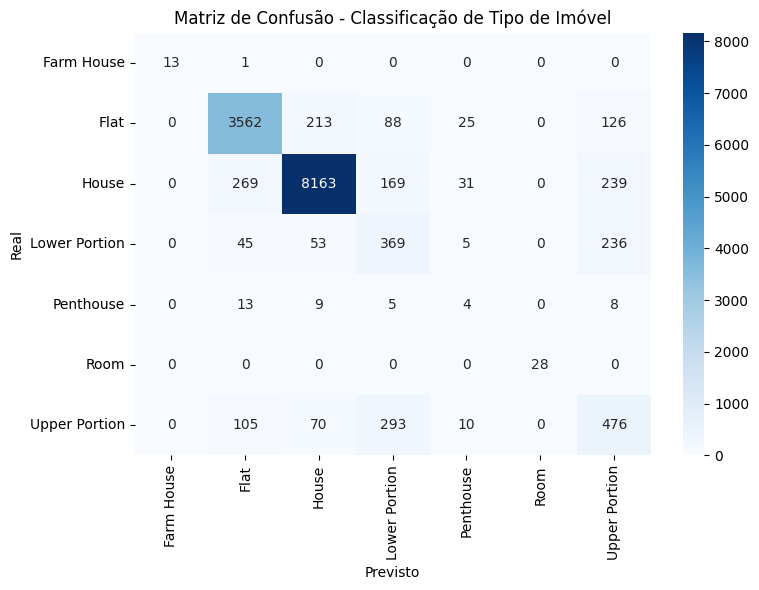

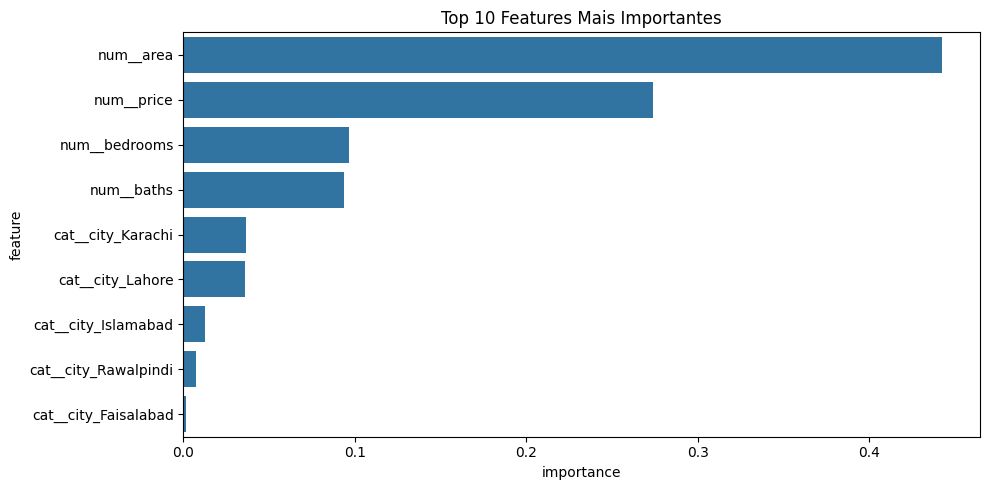

,price,area,bedrooms,baths,city,real_type,predicted_type
3509,96153.85,111.0,4,2,Karachi,Flat,Flat
64034,221153.85,126.0,4,5,Rawalpindi,House,House
66658,336.54,126.0,2,2,Rawalpindi,Lower Portion,Lower Portion
69493,865.38,405.0,3,3,Karachi,Upper Portion,Lower Portion
62263,730.77,202.0,2,3,Islamabad,House,Lower Portion
58085,73076.92,126.0,2,2,Rawalpindi,House,House
30079,384615.38,177.0,4,4,Lahore,House,House
58192,500000.00,212.0,4,2,Islamabad,House,House
26939,215384.62,126.0,3,3,Lahore,House,House
59670,2019.23,433.0,5,5,Karachi,House,House


In [15]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Matriz de Confusão - Classificação de Tipo de Imóvel')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

importances = model.named_steps['classifier'].feature_importances_
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=feat_imp.head(10), x='importance', y='feature')
plt.title('Top 10 Features Mais Importantes')
plt.tight_layout()
plt.show()

# Exportar previsões com dados reais
results = X_test.copy()
results['real_type'] = y_test.values
results['predicted_type'] = y_pred

results.head(50)
